In [35]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np

from astropy.table import Table
import sys, os, tqdm, glob
wdmodels_dir = os.environ['WDMODELS_DIR']
sys.path.append(wdmodels_dir)
import WD_models

plt.style.use("stefan.mplstyle")
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage[T1]{fontenc}\usepackage{lmodern}\usepackage{amsmath}",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

In [36]:
LOGG_SUN = 4.437

data = pd.read_csv("../data/tyler/tyler_wdms.csv")
data.rename({"phot_bp_rp_excess_factor": "bp_rp_excess"}, axis=1, inplace=True)
data = data.query("ruwe < 1.2 & bp_rp_excess < 1.2")

# Drop rows with failed fits (Teff/Mass/Logg == 0 or NaN)
data = data.query("Teff > 0 & Mass > 0 & Logg > 0").copy()

# Atmosphere classification from spectype
data["PDA"] = data["spectype"].str.startswith("DA").astype(float)
data["PDB"] = data["spectype"].str.startswith("DB").astype(float)

# Best-fit parameters (Tyler's fits)
data["teff_best"] = data["Teff"]
data["mass"]      = data["Mass"]
data["radius_best"] = np.sqrt(data["Mass"] * 10**(LOGG_SUN - data["Logg"]))

# Ages: Tyler provides values in Gyr; convert to log10(yr) for compatibility
def safe_log(x):
    return np.log10(np.clip(x, 1e-3, None) * 1e9)

data["log_age_cool"]    = safe_log(data["cool_age"])
data["log_age_cool_lo"] = safe_log(data["cool_age"] - data["e_cool_age_lower"])
data["log_age_cool_hi"] = safe_log(data["cool_age"] + data["e_cool_age_upper"])

# tot_age is NaN for ~1470 rows (low-mass WDs, no reliable IFMR);
# tot_age_error_upper is NaN for ~2781 rows — log_age_hi will be NaN for those.
# safe_log handles the 3 cases where tot_age - error_lower < 0 via clipping.
data["log_age"]    = safe_log(data["tot_age"])
data["log_age_lo"] = safe_log(data["tot_age"] - data["tot_age_error_lower"])
data["log_age_hi"] = safe_log(data["tot_age"] + data["tot_age_error_upper"])

In [37]:
len(data)

9164

In [38]:
def covariance_ellipse(x, y, n_std=1.0, center=None, **kwargs):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    width, height = 2 * n_std * np.sqrt(vals)
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    if center is None:
        center = (np.mean(x), np.mean(y))
    return patches.Ellipse(xy=center, width=width, height=height, angle=angle, fill=False, **kwargs)

def plot_dataset(xx, yy, ax, xlims, ylims,
                 xlabel=r"$\Delta \log g$ [\%]",
                 ylabel=r"$\Delta T_\text{eff}$ [\%]"):
    finite = np.isfinite(xx) & np.isfinite(yy)
    xx, yy = xx[finite], yy[finite]
    c = ax.hexbin(xx, yy, bins="log", cmap="managua", gridsize=150, vmin=1, vmax=1e2)
    for val in [3, 5, 10]:
        circle = patches.Circle((0, 0), val, edgecolor='blue', facecolor='none', ls='-', linewidth=2)
        ax.add_patch(circle)
    ax.text(0.05, 0.25,
        rf"$\langle \Delta T_\mathrm{{eff}} \rangle = {np.mean(yy):1.2f}\%$"
        "\n\n"
        rf"$\langle \Delta \log g \rangle = {np.mean(xx):1.2f}\%$",
        color="k", ha="left", va="top", fontsize=16, transform=ax.transAxes)
    cax = ax.inset_axes([0.5, 0.87, 0.4, 0.05])
    cbar = ax.get_figure().colorbar(c, cax=cax, orientation="horizontal")
    cbar.set_label("Count", fontsize=16, labelpad=2)
    cbar.ax.tick_params(labelsize=14)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim(xlims[0], xlims[1])
    ax.set_ylim(ylims[0], ylims[1])

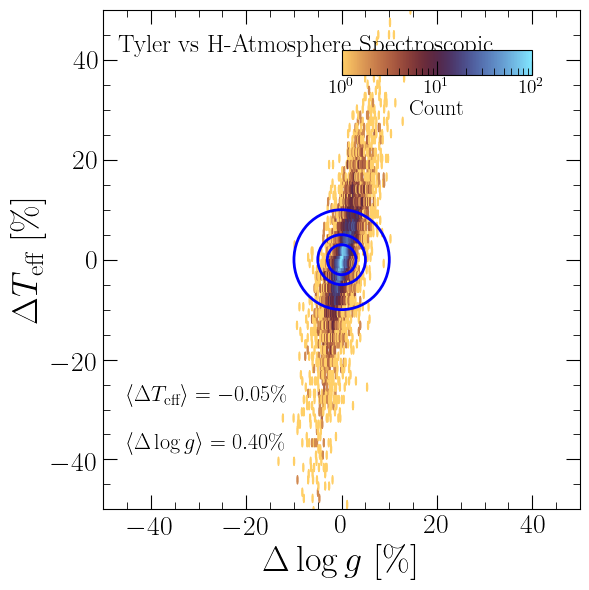

In [39]:
fig, ax = plt.subplots(figsize=(6, 6))

mask = data.mass > 0.45

# teff_H and logg_H are NGF21 H-atmosphere spectroscopic values.
# MassH is not in tyler_wdms, so we compare logg directly instead of radius.
teff_pct_err = 100 * (data.teff_H  - data.Teff)  / data.teff_H
logg_pct_err = 100 * (data.logg_H  - data.Logg)  / data.logg_H

plot_dataset(logg_pct_err[mask], teff_pct_err[mask], ax, (-50, 50), (-50, 50))
ax.text(0.03, 0.95, "Tyler vs H-Atmosphere Spectroscopic",
        ha="left", va="top", fontsize=18, transform=ax.transAxes)

fig.tight_layout()
fig.savefig("figures/comparison_tyler.pdf")

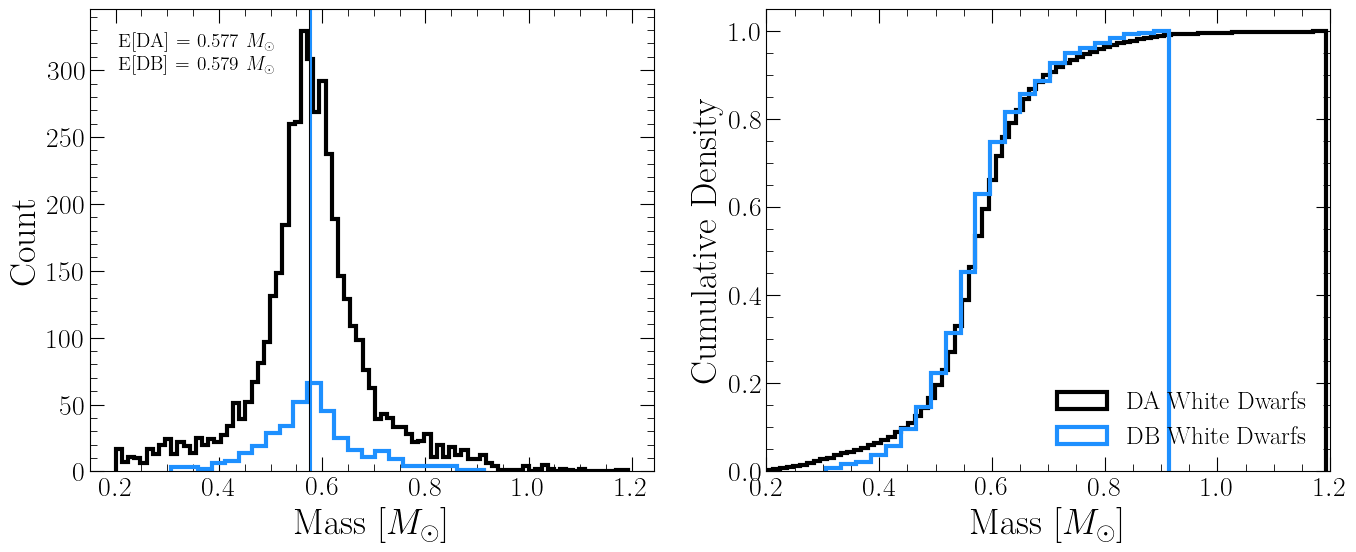

In [40]:
data_da = data.query("PDA > 0.8")
data_db = data.query("PDB > 0.8")

fig, ax = plt.subplots(ncols=2, figsize=(16, 6))

ax[0].hist(data_da.mass, histtype="step", linewidth=3, color="k", label="DA White Dwarfs")
ax[0].hist(data_db.mass, histtype="step", linewidth=3, color="dodgerblue", label="DB White Dwarfs")

mu_da = np.nanmedian(data_da.mass)
mu_db = np.nanmedian(data_db.mass)

ax[0].axvline(mu_da, c='k')
ax[0].axvline(mu_db, c='dodgerblue')
ax[0].text(0.05, 0.95,
    fr"E[DA] = {mu_da:.3f} $M_\odot$" "\n" fr"E[DB] = {mu_db:.3f} $M_\odot$",
    transform=ax[0].transAxes, va="top", ha="left", fontsize=14,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
ax[0].set_xlabel("Mass [$M_\\odot$]")
ax[0].set_ylabel("Count")

ax[1].hist(data_da.mass, histtype="step", linewidth=3, color="k", label="DA White Dwarfs",
           cumulative=True, density=True)
ax[1].hist(data_db.mass, histtype="step", linewidth=3, color="dodgerblue", label="DB White Dwarfs",
           cumulative=True, density=True)
ax[1].set_xlim(0.2, 1.2)
ax[1].set_xlabel("Mass [$M_\\odot$]")
ax[1].set_ylabel("Cumulative Density")
ax[1].legend(framealpha=0)

In [41]:
crys = pd.read_csv("../data/merge_data/crystallization.csv")

model = WD_models.load_model(low_mass_model='Bedard2020',
                             middle_mass_model='Bedard2020',
                             high_mass_model='Bedard2020',
                             atm_type='H',
                             HR_bands=('bp3-rp3', 'G3'))

logg_20pct  = model["HR_to_logg"](crys["bprp_20pct"].to_numpy(), crys["gabs_20pct"].to_numpy())
mass_20pct  = model["HR_to_mass"](crys["bprp_20pct"].to_numpy(), crys["gabs_20pct"].to_numpy())
teff_20pct  = 10**model["HR_to_logteff"](crys["bprp_20pct"].to_numpy(), crys["gabs_20pct"].to_numpy())

logg_80pct  = model["HR_to_logg"](crys["bprp_80pct"].to_numpy(), crys["gabs_80pct"].to_numpy())
mass_80pct  = model["HR_to_mass"](crys["bprp_80pct"].to_numpy(), crys["gabs_80pct"].to_numpy())
teff_80pct  = 10**model["HR_to_logteff"](crys["bprp_80pct"].to_numpy(), crys["gabs_80pct"].to_numpy())

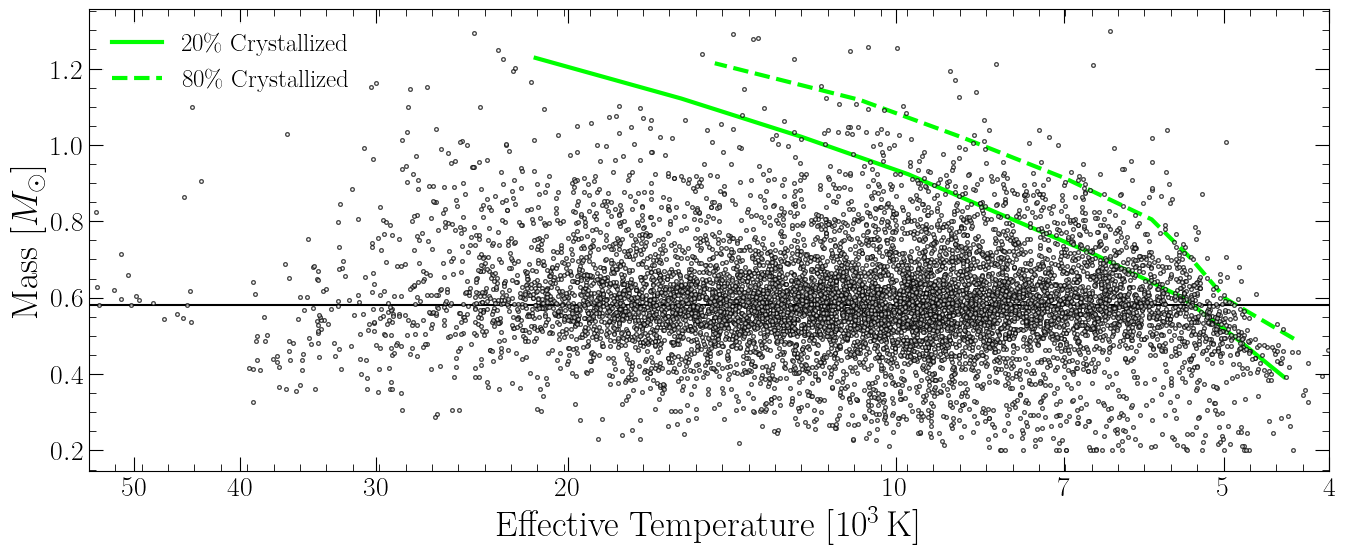

In [42]:
ifmr = pd.read_csv("../data/MESA_IFMR/ifmr_data.csv")

fig, ax = plt.subplots(figsize=(16, 6))

ax.scatter(np.log10(data.teff_best), data.mass,
           c='white', edgecolor="k", alpha=0.7, s=7, zorder=5, rasterized=True)
ax.axhline(np.nanmedian(data.mass), c="k")
ax.plot(np.log10(teff_20pct), mass_20pct, c="lime", lw=3, label="20\\% Crystallized")
ax.plot(np.log10(teff_80pct), mass_80pct, c="lime", ls="--", lw=3, label="80\\% Crystallized")

ax.invert_xaxis()
leg = ax.legend(frameon=True, facecolor="white", framealpha=0.8)
leg.get_frame().set_edgecolor("none")

ticks_kK = np.array([50, 40, 30, 20, 10, 7, 5, 4])
tick_locs = np.log10(ticks_kK * 1e3)
ax.set_xticks(tick_locs)
ax.set_xticklabels([f"{t:g}" for t in ticks_kK])
ax.set_xlabel(r"Effective Temperature $[10^3\,\mathrm{K}]$")
ax.set_ylabel(r"Mass [$M_\odot$]")
ax.set_xlim(np.log10(55000), np.log10(4000))

fig.savefig("figures/kieldiagram_tyler.pdf")

In [43]:
data_ages = pd.read_parquet("../data/merge/wbinary_gyro_ages_lu.pqt").reset_index()

tyler_cols = ["source_id", "Mass", "Teff", "cool_age", "e_cool_age_lower", "e_cool_age_upper",
              "tot_age", "tot_age_error_lower", "tot_age_error_upper", "spectype"]
tyler = pd.read_csv("../data/tyler/tyler_wdms.csv", usecols=tyler_cols)

data_ages = pd.merge(data_ages, tyler, left_on="wd_source_id", right_on="source_id", how="inner")

data_ages["PDA"] = data_ages["spectype"].str.startswith("DA").astype(float)
data_ages["mass"] = data_ages["Mass"]

data_ages["wd_age"]         = data_ages["tot_age"]
data_ages["wd_age_lo"]      = data_ages["tot_age_error_lower"]
data_ages["wd_age_hi"]      = data_ages["tot_age_error_upper"]
data_ages["wd_cool_age"]    = data_ages["cool_age"]
data_ages["wd_cool_age_lo"] = data_ages["e_cool_age_lower"]
data_ages["wd_cool_age_hi"] = data_ages["e_cool_age_upper"]

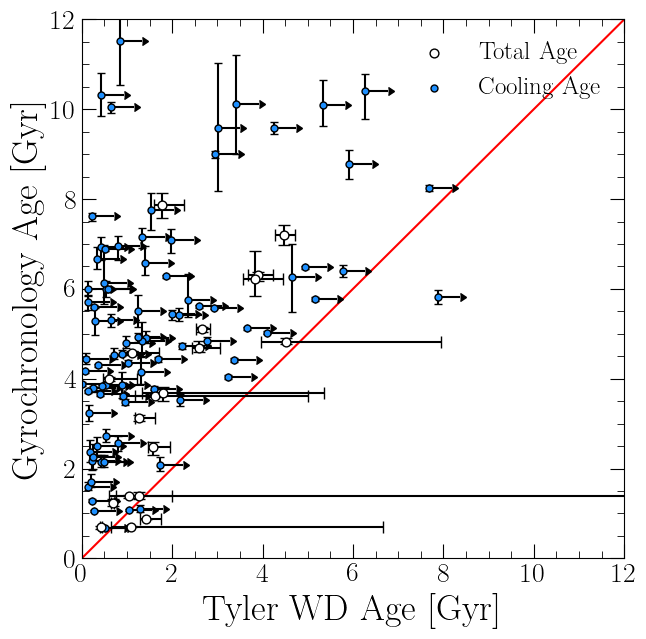

In [44]:
mask = (data_ages["mass"] > 0.63)

x     = data_ages.loc[mask,  "wd_age"].to_numpy()
xlo   = data_ages.loc[mask,  "wd_age_lo"].to_numpy()
xhi   = data_ages.loc[mask,  "wd_age_hi"].to_numpy()
y     = data_ages.loc[mask,  "Age"].to_numpy()
ylo   = np.abs(data_ages.loc[mask, "e_Age"].to_numpy())
yhi   = data_ages.loc[mask,  "E_Age"].to_numpy()

x_cool    = data_ages.loc[~mask, "wd_cool_age"].to_numpy()
xlo_cool  = data_ages.loc[~mask, "wd_cool_age_lo"].to_numpy()
xhi_cool  = data_ages.loc[~mask, "wd_cool_age_hi"].to_numpy()
y_cool    = data_ages.loc[~mask, "Age"].to_numpy()
ylo_cool  = np.abs(data_ages.loc[~mask, "e_Age"].to_numpy())
yhi_cool  = data_ages.loc[~mask, "E_Age"].to_numpy()

plt.scatter(x, y, c='white', edgecolor='k', zorder=3, label="Total Age", s=40)
plt.errorbar(x, y, xerr=[xlo, xhi], yerr=[ylo, yhi], fmt='None', c='k', capsize=4, zorder=2)

plt.scatter(x_cool, y_cool, c="dodgerblue", edgecolor="k", zorder=2, label="Cooling Age")
plt.errorbar(x_cool, y_cool, xerr=0.5, xlolims=True, yerr=[ylo_cool, yhi_cool],
             fmt="none", c="k", capsize=3, zorder=1)

plt.plot([-5, 20], [-5, 20], c='red', zorder=0)
plt.xlim(0, 12); plt.ylim(0, 12)
plt.xlabel("Tyler WD Age [Gyr]")
plt.ylabel("Gyrochronology Age [Gyr]")
plt.legend(framealpha=0)
plt.savefig("figures/gyro_comparison_tyler.pdf")

In [45]:
data_wdwd = pd.read_parquet("../data/merge/wbinary_heintz2022.pqt")

# data_wdwd already contains Tyler's fit columns (Teff, Mass, cool_age, tot_age, etc.)
# and ember's fit columns (teff_best, log_age, mass).
# Here we compare Tyler's WD age vs ember's WD age.

data_wdwd["wd_age_tyler"] = data_wdwd["tot_age"]
data_wdwd["wd_age_tyler_lo"] = data_wdwd["tot_age_error_lower"]
data_wdwd["wd_age_tyler_hi"] = data_wdwd["tot_age_error_upper"]

data_wdwd["wd_age_ember"] = 10**(data_wdwd["log_age"] - 9)
data_wdwd["wd_age_ember_lo"] = 10**(data_wdwd["log_age_lo"] - 9)
data_wdwd["wd_age_ember_hi"] = 10**(data_wdwd["log_age_hi"] - 9)

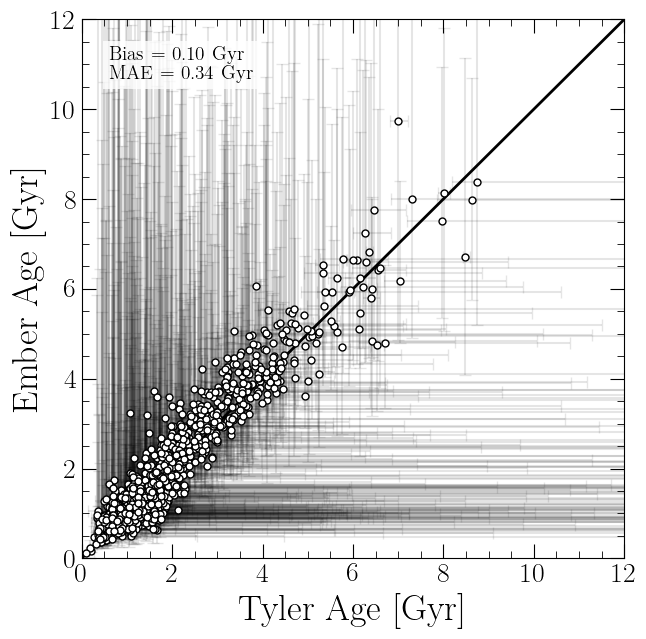

In [46]:
mask = (data_wdwd.mass > 0.63) & (data_wdwd.Mass > 0.63)

x   = data_wdwd.loc[mask, "wd_age_tyler"].to_numpy()
xlo = data_wdwd.loc[mask, "wd_age_tyler_lo"].to_numpy()
xhi = data_wdwd.loc[mask, "wd_age_tyler_hi"].to_numpy()

y   = data_wdwd.loc[mask, "wd_age_ember"].to_numpy()
ylo = y - data_wdwd.loc[mask, "wd_age_ember_lo"].to_numpy()
yhi = data_wdwd.loc[mask, "wd_age_ember_hi"].to_numpy() - y

res  = y - x
bias = np.nanmean(res)
mae  = np.nanmean(np.abs(res))

plt.scatter(x, y, c='white', edgecolor='k', zorder=1)
plt.errorbar(x, y, xerr=[xlo, xhi], yerr=[ylo, yhi], fmt='None',
             c='k', alpha=0.1, capsize=4, zorder=0)
plt.plot([-1, 20], [-1, 20], c='k', lw=2, zorder=0)
plt.xlim(0, 12); plt.ylim(0, 12)
plt.xlabel("Tyler Age [Gyr]")
plt.ylabel("Ember Age [Gyr]")
plt.text(0.05, 0.95,
    fr"Bias = {bias:.2f} Gyr" "\n" fr"MAE = {mae:.2f} Gyr",
    transform=plt.gca().transAxes, va="top", ha="left", fontsize=14,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
plt.savefig("figures/tyler_vs_ember_ages.pdf")

In [47]:
data["wd_age"]      = 10**(data["log_age"] - 9)
data["wd_age_lo"]   = 10**(data["log_age_lo"] - 9)
data["wd_age_hi"]   = 10**(data["log_age_hi"] - 9)
data["wd_cool_age"]    = 10**(data["log_age_cool"] - 9)
data["wd_cool_age_lo"] = 10**(data["log_age_cool_lo"] - 9)
data["wd_cool_age_hi"] = 10**(data["log_age_cool_hi"] - 9)

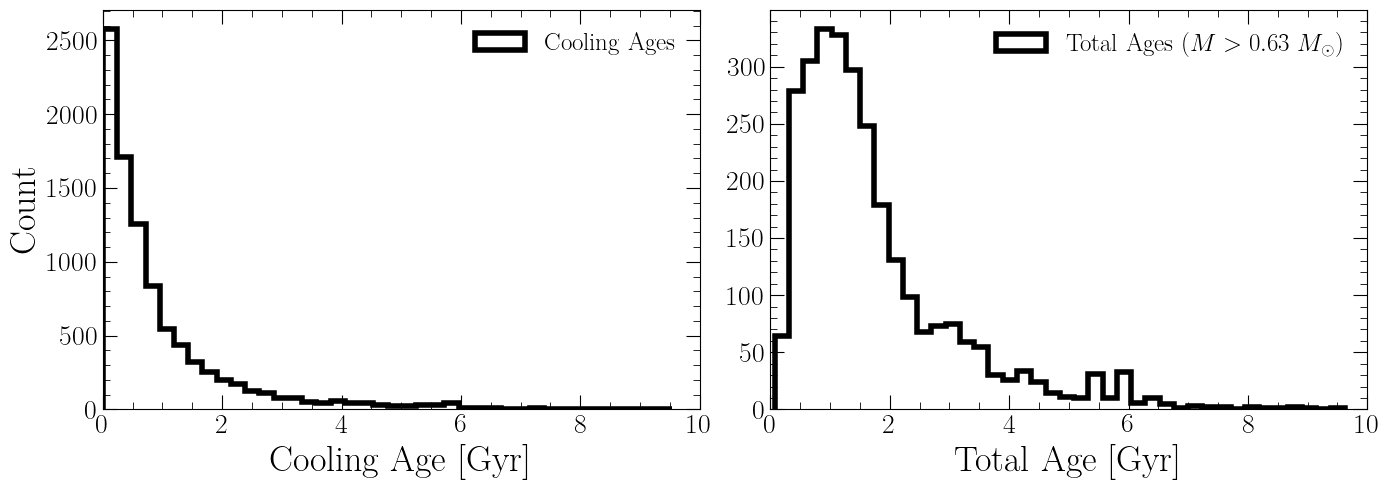

In [48]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].hist(data["wd_cool_age"].dropna(), histtype="step", color="k", linewidth=4,
           label="Cooling Ages", bins=40)
ax[0].set_xlabel("Cooling Age [Gyr]"); ax[0].set_ylabel("Count")
ax[0].set_xlim(0, 10)
ax[0].legend(framealpha=0)

# Apply mass > 0.63 mask to suppress unphysically large ages from low-mass WDs
# (tot_age can reach 3000+ Gyr via IFMR extrapolation for M_init < 1 Msun)
mask_mass = data["mass"] > 0.63
ax[1].hist(data.loc[mask_mass, "wd_age"].dropna(), histtype="step", color="k", linewidth=4,
           label=r"Total Ages ($M > 0.63~M_\odot$)", bins=40)
ax[1].set_xlabel("Total Age [Gyr]")
ax[1].set_xlim(0, 10)
ax[1].legend(framealpha=0)

fig.tight_layout()
fig.savefig("figures/age_dist_tyler.pdf")

In [49]:
len(data)

9164